In [ ]:
import os
if not os.path.exists("/content/Machine_Learning"):
    !git clone https://github.com/Susantoco/Machine_Learning.git
%cd /content/Machine_Learning
!python setup_colab.py

In [ ]:
import os
os.kill(os.getpid(), 9)

# **Logistic Regression for Rental Price Prediction**
This project is a part of an assignment from HCMUT Machine Learning course, semester 252. The goal is to implement a traditional machine learning pipeline, then evaluate its performance. A Logistic Regression model is implemented to predict rent price here, while other models are also implemented, based on the same data, in different notebooks.

# **1. Setup**

This section configures the Google Colab environment and imports the necessary libraries. The setup ensures a consistent workspace and provides the tools required for data processing, visualization, and modeling.

- **Environment Setup**: Mounting Google Drive and verifying the Python executable for path consistency.
- **Data Manipulation**: `pandas` and `numpy` are utilized for efficient data handling, cleaning, and numerical operations on the rental dataset.
- **Visualization**: `matplotlib` and `seaborn` are used to generate plots, analyze feature distributions, and visualize classification results.
- **Machine Learning**: `sklearn` modules are employed to build a robust modeling pipeline:
    - `MaxAbsScaler`: Scales features by their maximum absolute value, ideal for sparse data while preserving zeros.
    - `LogisticRegression`: The core classification algorithm used to predict rental price categories.
    - `GridSearchCV`: Facilitates systematic hyperparameter tuning to find the optimal model configuration via cross-validation.

In [ ]:
import sys
print(sys.executable)

/usr/bin/python3
Mounted at /content/drive


In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

from sklearn.model_selection import GridSearchCV

# Global Plotting Configuration
plt.rcParams['figure.figsize'] = (8, 6)

# **2. Data**

The data used in this project was preprocessed and explored in a separate notebook. Please refer to the previous EDA and preprocessing step for more details.

In [ ]:
train_df = pd.read_csv("features/processed/train.csv")
val_df = pd.read_csv("features/processed/val.csv")
test_df = pd.read_csv("features/processed/test.csv")

print(f"Training Data: {train_df.shape}")
print(f"Validation Data: {val_df.shape}")

Training Data: (172064, 65)
Validation Data: (43016, 65)


### **2.1. Initial Data Inspection and Class Imbalance**
Logistic Regression is fundamentally a **classifier**. By binning the continuous `totalRent`, a regression task is converted into a multi-class classification task. The distribution of rent is examined using manual bins to identify potential class imbalances.

In [4]:
bins = [0, 250, 500, 750, 1000, 1250, 1500, float("inf")]
labels = ["0-250", "250-500", "500-750", "750-1000", "1000-1250", "1250-1500", "1500+"]

rentRanges = pd.cut(train_df["totalRent"], bins=bins, labels=labels, right=False)

dist = rentRanges.value_counts().sort_index()
perc = rentRanges.value_counts(normalize=True).sort_index() * 100
summary = pd.DataFrame({'Count': dist, 'Percentage': perc})
display(summary)

print(f"\nMajority class (500-750) ratio to minority (0-250): {dist['500-750']/dist['0-250']:.2f}:1")

,Count,Percentage
totalRent,,
0-250,1575,0.915357
250-500,42549,24.728589
500-750,76282,44.333504
750-1000,24310,14.128464
1000-1250,13183,7.661684
1250-1500,8656,5.030686
1500+,5509,3.201716



Majority class (500-750) ratio to minority (0-250): 48.43:1


### **2.2. Quantile Binning for Balanced Classes**
As can be seen from the table above, manual binning often leads to high imbalance, which can bias the model toward the majority class.

**Strategy:**
- **Quantile Binning:** `rank(method='first')` combined with `qcut` is used to ensure each category ('budget', 'mid_range', 'premium') has an equal number of samples.
- **Threshold Mapping:** Price edges are extracted from the training set and applied to the validation and test sets to maintain consistency.

In [5]:
price_labels = ['budget', 'mid_range', 'premium']
num_labels = len(price_labels)

rentRank = train_df['totalRent'].rank(method='first')
train_df['rentCategory'], bins_edges = pd.qcut(rentRank, q=num_labels, retbins=True, labels=price_labels)

# Map the min/max totalRent for each rank-based bin to apply to val/test
price_bins = [train_df[train_df['rentCategory'] == label]['totalRent'].min() for label in price_labels] + [train_df['totalRent'].max() + 1]
price_bins[0] = 0
print(f"Calculated Price Bins: {price_bins}")

val_df['rentCategory'] = pd.cut(val_df['totalRent'], bins=price_bins, labels=price_labels, include_lowest=True)
test_df['rentCategory'] = pd.cut(test_df['totalRent'], bins=price_bins, labels=price_labels, include_lowest=True)

balanced_dist = train_df['rentCategory'].value_counts().sort_index()
balanced_perc = train_df['rentCategory'].value_counts(normalize=True).sort_index() * 100

print("Price Bin Thresholds (Approx):", [round(b, 2) for b in price_bins])
display(pd.DataFrame({'Count': balanced_dist, 'Percentage': balanced_perc}))

Calculated Price Bins: [0, 560.0, 700.0, 1758.53]
Price Bin Thresholds (Approx): [0, 560.0, 700.0, 1758.53]


,Count,Percentage
rentCategory,,
budget,57355,33.333527
mid_range,57354,33.332946
premium,57355,33.333527


# **3. Feature - Target Split**
The data set is split into:
- **x**: input features
- **y**: target `rentCategory`

A controlled configuration without `baseRent` is also prepared.

### **3.1. Model 1: Feature Set Excluding `baseRent`**
A baseline feature set is prepared that excludes `baseRent` and `totalRent` to evaluate the predictive power of secondary property characteristics.

In [6]:
x_train_without_baseRent = train_df.drop(columns=["totalRent", "baseRent", "rentCategory"])
y_train_without_baseRent = train_df["rentCategory"]

x_val_without_baseRent = val_df.drop(columns=["totalRent","baseRent", "rentCategory"])
y_val_without_baseRent = val_df["rentCategory"]

x_test_without_baseRent = test_df.drop(columns=["totalRent", "baseRent", "rentCategory"])
y_test_without_baseRent = test_df["rentCategory"]

### **3.2. Model 2: Feature Set Including `baseRent`**
A secondary feature set is prepared that includes `baseRent` to quantify the performance gain when the primary cost driver is available to the model.

In [7]:
x_train_with_baseRent = train_df.drop(columns=["totalRent", "rentCategory"])
y_train_with_baseRent = train_df["rentCategory"]

x_val_with_baseRent = val_df.drop(columns=["totalRent", "rentCategory"])
y_val_with_baseRent = val_df["rentCategory"]

x_test_with_baseRent = test_df.drop(columns=["totalRent", "rentCategory"])
y_test_with_baseRent = test_df["rentCategory"]

# **4. Training & Evaluation: Model 1 (No `baseRent`)**
In this section, a machine learning pipeline is defined, hyperparameter tuning is performed using cross-validation, and the resulting model is evaluated on the unseen Validation set.

In [8]:
# Pipeline 1: Without baseRent
pipeline_nobr = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('logistic', LogisticRegression())
])

param_grid = [
    {
        'logistic__C': [0.1, 1, 10],
        'logistic__penalty': ['l1', 'l2'],
        'logistic__solver': ['saga'],
        'logistic__max_iter': [2000],
        'logistic__tol': [0.001]
    },
    {
        'logistic__C': [0.1, 1, 10],
        'logistic__penalty': ['l2'],
        'logistic__solver': ['newton-cholesky'],
        'logistic__max_iter': [2000],
        'logistic__tol': [0.001]
    }
]

grid_nobr = GridSearchCV(
    pipeline_nobr,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_nobr.fit(x_train_without_baseRent, y_train_without_baseRent)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MaxAbsScaler()),
                                       ('logistic', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'logistic__C': [0.1, 1, 10],
                          'logistic__max_iter': [2000],
                          'logistic__penalty': ['l1', 'l2'],
                          'logistic__solver': ['saga'],
                          'logistic__tol': [0.001]},
                         {'logistic__C': [0.1, 1, 10],
                          'logistic__max_iter': [2000],
                          'logistic__penalty': ['l2'],
                          'logistic__solver': ['newton-cholesky'],
                          'logistic__tol': [0.001]}],
             scoring='f1_weighted', verbose=1)

In [9]:
# Extract the best performing model and generate predictions for evaluation
print(f"Best Parameters (No baseRent): {grid_nobr.best_params_}")
print(f"Best CV F1 (Weighted) (No baseRent): {grid_nobr.best_score_:.4f}")

model_nobr = grid_nobr.best_estimator_

y_val_pred_nobr = model_nobr.predict(x_val_without_baseRent)

Best Parameters (No baseRent): {'logistic__C': 0.1, 'logistic__max_iter': 2000, 'logistic__penalty': 'l1', 'logistic__solver': 'saga', 'logistic__tol': 0.001}
Best CV F1 (Weighted) (No baseRent): 0.6482


Classification Report (No baseRent):
              precision    recall  f1-score   support

      budget       0.75      0.84      0.79     14536
   mid_range       0.50      0.44      0.47     14327
     premium       0.68      0.68      0.68     14153

    accuracy                           0.65     43016
   macro avg       0.64      0.65      0.65     43016
weighted avg       0.64      0.65      0.65     43016



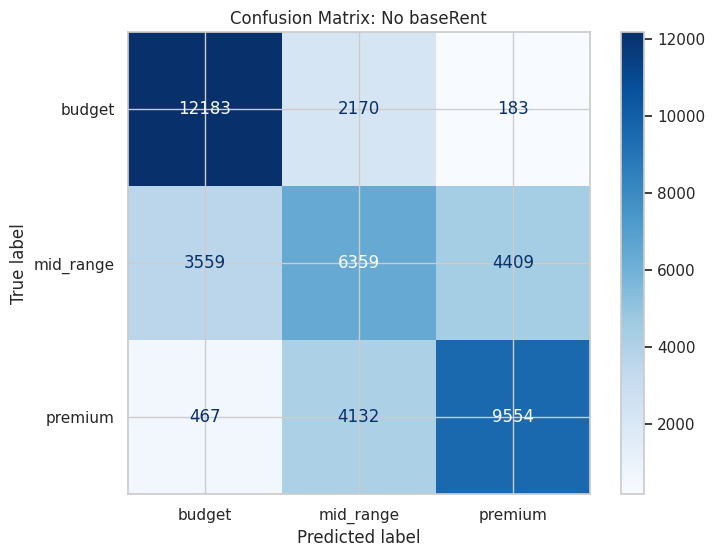

In [21]:
# Visualize Validation Performance
print("Classification Report (No baseRent):")
print(classification_report(y_val_without_baseRent, y_val_pred_nobr))

fig_nobr_val, ax_nobr_val = plt.subplots()
cm_nobr_val = confusion_matrix(y_val_without_baseRent, y_val_pred_nobr)
disp_nobr_val = ConfusionMatrixDisplay(confusion_matrix=cm_nobr_val, display_labels=price_labels)
disp_nobr_val.plot(cmap='Blues', ax=ax_nobr_val)
plt.title('Confusion Matrix: No baseRent')
plt.show()


Model 1 demonstrates consistent performance on the Validation set.

#### **Overall Performance**
- **Validation Accuracy:** 65%
- **F1-Score (Weighted):** 0.65

#### **Category Breakdown**
- **Best Performance (Budget):** High effectiveness with a **75% precision** and **84% recall**. The model captures low-price characteristics effectively.
- **Moderate Performance (Premium):** Solid performance with an **F1-score of 0.67**.
- **Lowest Performance (Mid-range):** Significant difficulty in classification, evidenced by an **F1-score of 0.47**. The confusion matrix reveals that mid-range properties are frequently misclassified as either budget or premium, indicating high feature overlap in the middle price tier.

The model serves as a strong baseline, performing nearly double the accuracy of random guessing (33%). The validation metrics suggest the quantile binning strategy and the `MaxAbsScaler` pipeline are robust, though identifying 'Mid-range' properties remains a challenge without additional features like `baseRent`.

# **5. Training & Evaluation: Model 2 (With `baseRent`)**
The training process is repeated using the expanded feature set to observe how much the inclusion of the base rental price improves classification accuracy.

In [11]:
# Pipeline 2: With baseRent
pipeline_wbr = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('logistic', LogisticRegression())
])

grid_wbr = GridSearchCV(
    pipeline_wbr,
    param_grid, # Using same grid config as above
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_wbr.fit(x_train_with_baseRent, y_train_with_baseRent)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MaxAbsScaler()),
                                       ('logistic', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'logistic__C': [0.1, 1, 10],
                          'logistic__max_iter': [2000],
                          'logistic__penalty': ['l1', 'l2'],
                          'logistic__solver': ['saga'],
                          'logistic__tol': [0.001]},
                         {'logistic__C': [0.1, 1, 10],
                          'logistic__max_iter': [2000],
                          'logistic__penalty': ['l2'],
                          'logistic__solver': ['newton-cholesky'],
                          'logistic__tol': [0.001]}],
             scoring='f1_weighted', verbose=1)

In [12]:
# Extract the best performing model and generate predictions for evaluation
print(f"Best Parameters (With baseRent): {grid_wbr.best_params_}")
print(f"Best CV F1 (Weighted) (With baseRent): {grid_wbr.best_score_:.4f}")

model_wbr = grid_wbr.best_estimator_

y_val_pred_wbr = model_wbr.predict(x_val_with_baseRent)

Best Parameters (With baseRent): {'logistic__C': 0.1, 'logistic__max_iter': 2000, 'logistic__penalty': 'l1', 'logistic__solver': 'saga', 'logistic__tol': 0.001}
Best CV F1 (Weighted) (With baseRent): 0.7769


Classification Report (With baseRent):
              precision    recall  f1-score   support

      budget       0.84      0.90      0.87     14536
   mid_range       0.66      0.68      0.67     14327
     premium       0.82      0.75      0.79     14153

    accuracy                           0.78     43016
   macro avg       0.78      0.77      0.77     43016
weighted avg       0.78      0.78      0.78     43016



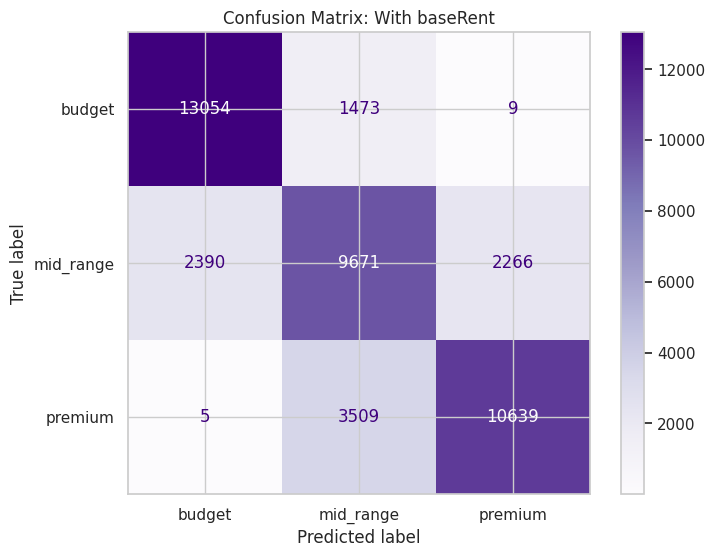

In [13]:
# Visualize Validation Performance
print("Classification Report (With baseRent):")
print(classification_report(y_val_with_baseRent, y_val_pred_wbr))

fig_wbr_val, ax_wbr_val = plt.subplots()
cm_wbr_val = confusion_matrix(y_val_with_baseRent, y_val_pred_wbr)
disp_wbr_val = ConfusionMatrixDisplay(confusion_matrix=cm_wbr_val, display_labels=price_labels)
disp_wbr_val.plot(cmap='Purples', ax=ax_wbr_val)
plt.title('Confusion Matrix: With baseRent')
plt.show()

The inclusion of **baseRent** in Model 2 leads to a substantial improvement in predictive performance compared to the baseline Model 1.

#### **Performance Gains**
- **Accuracy & F1-Score:** The overall accuracy increased from 65% to **78%**.
- **Weighted F1-Score:** Improved to **0.78**, indicating a more robust model across all classes.

#### **Category Improvements**
- **Budget & Premium:** Both categories saw an increase in F1-scores (reaching 0.87 and 0.79 respectively), as the model better distinguishes low-end and high-end properties.
- **Mid-range Resolution:** The 'mid-range' category, which was previously a point of failure, saw its F1-score jump from 0.47 to **0.67**. While some overlap with other categories remains, the addition of `baseRent` provides the necessary signal to identify the middle-tier properties more effectively.

Model 2 demonstrates that the base rental price is the most significant predictor for the total rent category. While secondary features (Model 1) provide a solid foundation, the primary cost driver is essential for achieving high classification precision on the validation set, particularly in distinguishing overlapping middle-market segments.

# **6. Comparative Analysis: Model 1 vs. Model 2**

This section provides a direct comparison between the two modeling approaches to quantify the impact of including the primary cost driver (`baseRent`) on classification performance.

### **6.1. Error Metric Comparison**

The misclassification rate (1 - Accuracy) is compared for both models using the validation set to determine the relative reduction in error.

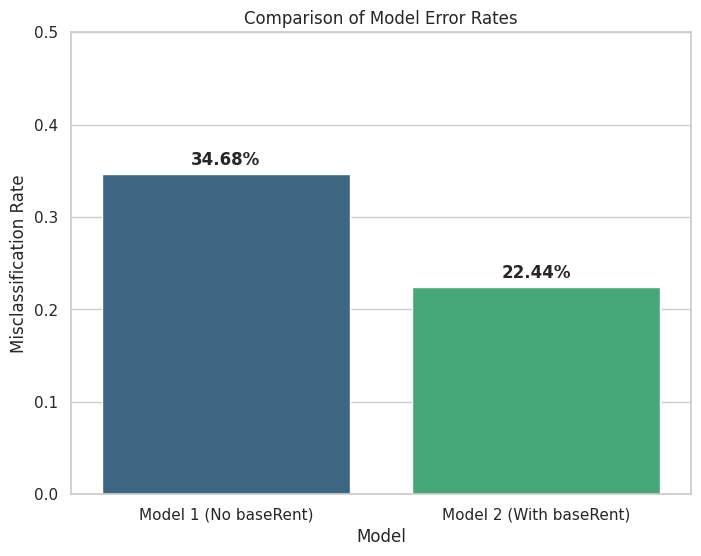

,Model,Error Rate
0,Model 1 (No baseRent),0.346848
1,Model 2 (With baseRent),0.224382


In [14]:
# Calculate error rates for both models on the validation set
error_nobr = 1 - accuracy_score(y_val_without_baseRent, y_val_pred_nobr)
error_wbr = 1 - accuracy_score(y_val_with_baseRent, y_val_pred_wbr)

# Prepare comparison data
comparison_df = pd.DataFrame({
    'Model': ['Model 1 (No baseRent)', 'Model 2 (With baseRent)'],
    'Error Rate': [error_nobr, error_wbr]
})

# Visualization of Error Rates
plt.figure()
sns.barplot(data=comparison_df, x='Model', y='Error Rate', hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Model Error Rates')
plt.ylabel('Misclassification Rate')
plt.ylim(0, 0.5)

# Annotate bars with percentage values
for i, val in enumerate(comparison_df['Error Rate']):
    plt.text(i, val + 0.01, f'{val:.2%}', ha='center', fontweight='bold')

plt.show()

display(comparison_df)

The reduction in the misclassification rate by approximately **12.22 percentage points** (a ~35% relative improvement in error) reveals critical insights into the underlying model dynamics:

*   Model 1, which excludes `baseRent`, suffers from **high bias**. By omitting the strongest predictor of total rent, the model was mathematically limited, regardless of the amount of data or complexity of the algorithm. Model 2 reduces this bias by incorporating the primary cost driver.
*   The jump in performance demonstrates that while secondary characteristics (living space, year constructed, etc.) provide a baseline signal (65% accuracy), they are insufficient to resolve the overlap between price categories—particularly the 'mid-range' tier.
*   The inclusion of `baseRent` provides the necessary linear separation for the Logistic Regression solver to distinguish between the quantile-based categories with much higher confidence.

### **6.2. Predicted vs. Actual Distribution**

To further evaluate model bias, a comparision of the distribution of the predicted classes against the actual ground truth from the validation set is shown. This highlights whether the models are systematically over-predicting or under-predicting specific price tiers.

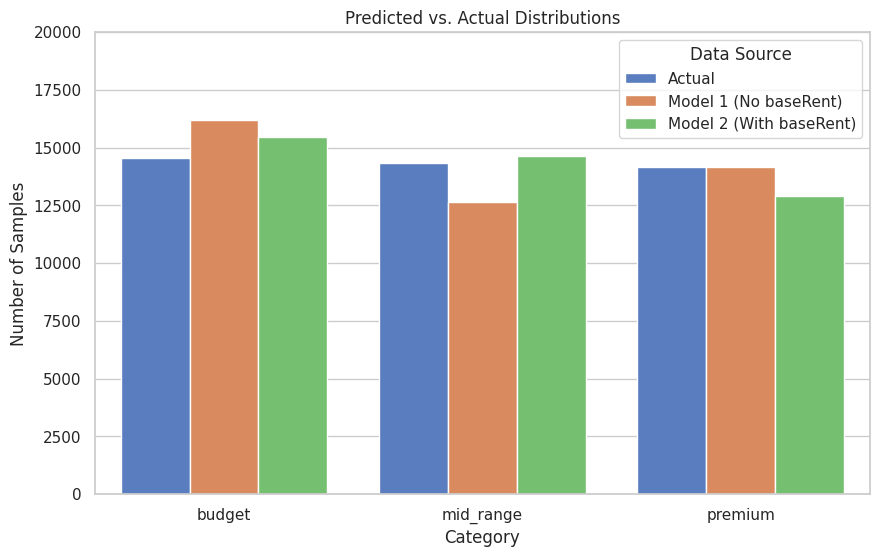

Source,Actual,Model 1 (No baseRent),Model 2 (With baseRent)
Category,,,
budget,14536,16209,15449
mid_range,14327,12661,14653
premium,14153,14146,12914


In [15]:
# Create a DataFrame for distribution comparison using original validation counts
actual_counts = y_val_without_baseRent.value_counts().sort_index()
pred_nobr_counts = pd.Series(y_val_pred_nobr).value_counts().sort_index()
pred_wbr_counts = pd.Series(y_val_pred_wbr).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Category': price_labels,
    'Actual': actual_counts.values,
    'Model 1 (No baseRent)': pred_nobr_counts.values,
    'Model 2 (With baseRent)': pred_wbr_counts.values
}).melt(id_vars='Category', var_name='Source', value_name='Count')

# Visualization with axis extended to 20,000
plt.figure(figsize=(10, 6))
sns.barplot(data=dist_df, x='Category', y='Count', hue='Source', palette='muted')
plt.title('Predicted vs. Actual Distributions')
plt.ylabel('Number of Samples')
plt.ylim(0, 20000)
plt.legend(title='Data Source')
plt.show()

display(dist_df.pivot(index='Category', columns='Source', values='Count'))

Analyzing the predicted distributions against the actual validation counts reveals how each model handles class-specific characteristics:

*   Model 1 significantly over-predicts the 'budget' category and under-predicts the 'mid-range' category. Without `baseRent`, the model defaults to labeling properties as 'budget' when features are ambiguous, failing to capture the nuances of the middle market.
*   The distribution for Model 2 tracks the 'Actual' ground truth much more closely. The most notable improvement is in the 'mid-range' tier, where the predicted count is now nearly identical to the actual count.
*   Residual Errors: Both models show a slight tendency to under-predict 'premium' properties compared to the actual count, though Model 2 significantly narrows this gap. This suggests that while `baseRent` is the primary driver, there may still be extreme 'premium' outliers that require more complex features to classify perfectly.

### **6.3. Residual Analysis**

*   Most residual errors in both models occur between adjacent categories (e.g., a 'mid_range' property being classified as 'budget'). This is because the 'Total Rent' thresholds are not hard boundaries but rather represent a continuum where properties near the edge of a bin share nearly identical features.
*   Even with `baseRent`, the 'mid_range' category has the lowest F1-score. This indicates that properties in the center of the market have the highest variance in their additional costs (service charges, utilities), making them the most difficult to pin down to a specific category based on base price alone.
*   The 'premium' category residuals are low, indicating that high-end properties possess unique combinations of features that the Logistic Regression model can separate with high confidence.

### **6.4. The Impact of Feature Correlation: `baseRent` vs. `totalRent`**

The dramatic performance improvement observed in Model 2 warrants a closer look at the relationship between the features and the target variable.

Pearson Correlation between baseRent and totalRent: 0.8533


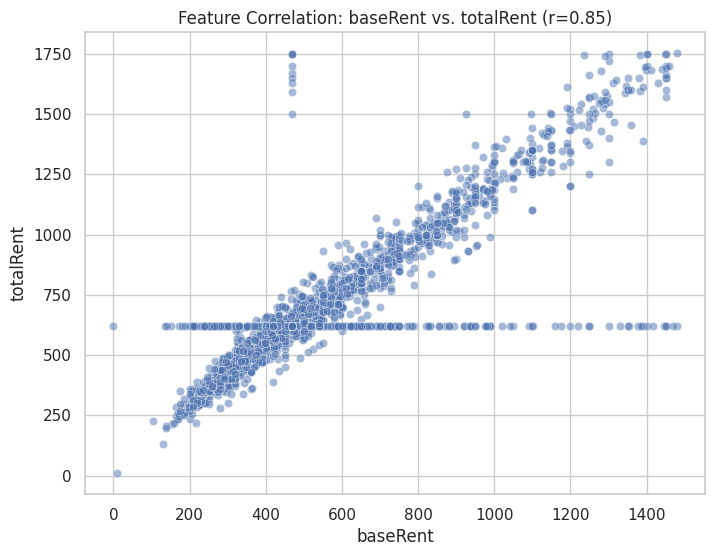

In [16]:
# Calculate the Pearson correlation between baseRent and totalRent
correlation = train_df[['baseRent', 'totalRent']].corr().iloc[0, 1]
print(f"Pearson Correlation between baseRent and totalRent: {correlation:.4f}")

# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_df.sample(2000, random_state=42), x='baseRent', y='totalRent', alpha=0.5)
plt.title(f'Feature Correlation: baseRent vs. totalRent (r={correlation:.2f})')
plt.show()

As shown above, `baseRent` and `totalRent` share an extremely high positive correlation.

While Model 1 has lower accuracy (65%), it offers higher inferential value. By removing the dominant `baseRent` feature, Model 1 forces the algorithm to find patterns in 'distal' features like `livingSpace`, `yearConstructed`, and `serviceCharge`.

**Conclusion:**
- Model 2 is a superior predictor for practical applications when baseRent is known
- Model 1 is more useful for understanding how specific property characteristics (independent of the base price tag) contribute to a property's market positioning.

# **7. Final Model Training and Test Set Evaluation**

To maximize the model's learning potential, the training and validation sets are combined. The final model is then trained using the best parameters found for Model 2 and evaluated on both the final training set, and the previously unseen test set.

In [17]:
x_final_train = pd.concat([x_train_with_baseRent, x_val_with_baseRent])
y_final_train = pd.concat([y_train_with_baseRent, y_val_with_baseRent])

final_model = clone(model_wbr)

##  **7.1. Training the model on the final combined set**

Classification Report (Combined Training + Validation Set):
              precision    recall  f1-score   support

      budget       0.84      0.90      0.87     71891
   mid_range       0.66      0.68      0.67     71681
     premium       0.83      0.75      0.79     71508

    accuracy                           0.78    215080
   macro avg       0.78      0.78      0.78    215080
weighted avg       0.78      0.78      0.78    215080



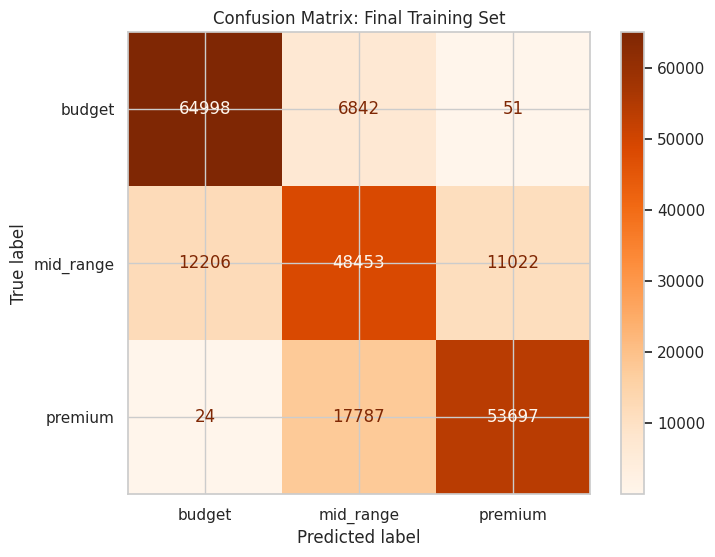

In [18]:
final_model.fit(x_final_train, y_final_train)

y_final_train_pred = final_model.predict(x_final_train)

print("Classification Report (Combined Training + Validation Set):")
print(classification_report(y_final_train, y_final_train_pred))

# Plot Confusion Matrix for Training Set
fig_train_final, ax_train_final = plt.subplots()
cm_train_final = confusion_matrix(y_final_train, y_final_train_pred)
disp_train_final = ConfusionMatrixDisplay(confusion_matrix=cm_train_final, display_labels=price_labels)
disp_train_final.plot(cmap='Oranges', ax=ax_train_final)
plt.title('Confusion Matrix: Final Training Set')
plt.show()

##  **7.2. Test set evaluation**

Classification Report (Test Set):
              precision    recall  f1-score   support

      budget       0.85      0.90      0.87     18135
   mid_range       0.66      0.68      0.67     17726
     premium       0.83      0.76      0.79     17909

    accuracy                           0.78     53770
   macro avg       0.78      0.78      0.78     53770
weighted avg       0.78      0.78      0.78     53770



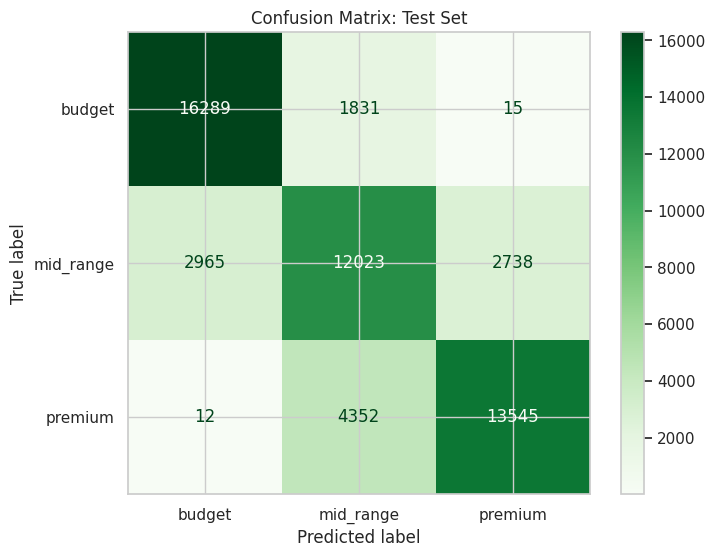

In [19]:
y_test_pred = final_model.predict(x_test_with_baseRent)

print("Classification Report (Test Set):")
print(classification_report(y_test_with_baseRent, y_test_pred))

# Plot final Confusion Matrix
fig_test, ax_test = plt.subplots()
cm_test = confusion_matrix(y_test_with_baseRent, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=price_labels)
disp_test.plot(cmap='Greens', ax=ax_test)
plt.title('Confusion Matrix: Test Set')
plt.show()

### **7.3. Performance Comparison: Combined Training vs. Test Set**

Comparing the metrics between the final combined training set and the unseen test set allows us to evaluate the model's generalization capability.

,Metric,Final Training Set,Test Set
0,Accuracy,0.777143,0.778445
1,Weighted F1-Score,0.776491,0.778161


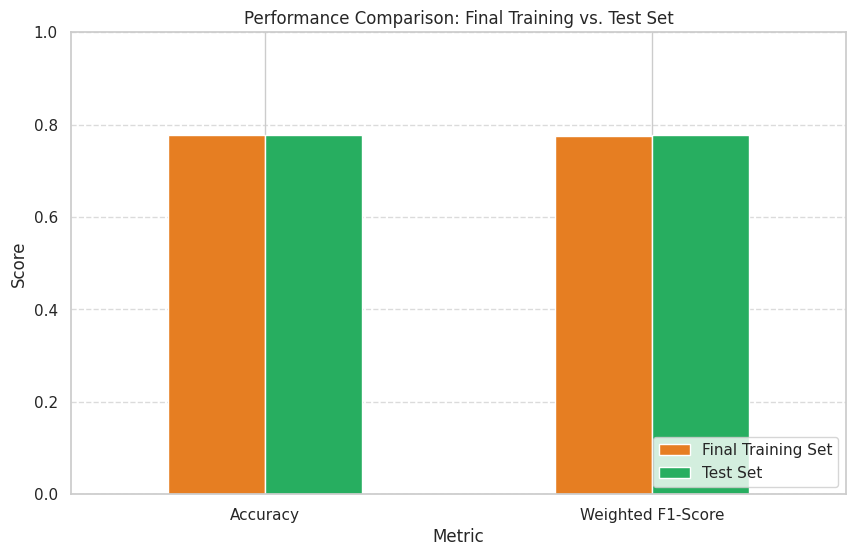

In [20]:
# Extract accuracy and weighted F1 for comparison
train_acc = accuracy_score(y_final_train, y_final_train_pred)
test_acc = accuracy_score(y_test_with_baseRent, y_test_pred)

train_f1 = f1_score(y_final_train, y_final_train_pred, average='weighted')
test_f1 = f1_score(y_test_with_baseRent, y_test_pred, average='weighted')

performance_comp = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted F1-Score'],
    'Final Training Set': [train_acc, train_f1],
    'Test Set': [test_acc, test_f1]
})

display(performance_comp)

# Visualize the comparison
performance_comp.set_index('Metric').plot(kind='bar', figsize=(10, 6), rot=0, color=['#e67e22', '#27ae60'])
plt.title('Performance Comparison: Final Training vs. Test Set')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*   The performance on the test set (78% accuracy) is nearly identical to the performance on the combined training set. This indicates that the Logistic Regression model, regularized by the `GridSearchCV` parameters, has reached an optimal balance without memorizing the training data.
*   Since the weighted F1-score also remains stable (~0.78), we can conclude that the model's ability to handle class-specific nuances (like the difficult 'mid-range' tier) is consistent across different data samples.
*   The model is robust and provides high predictive confidence for real-world deployment on similar rental data distributions.

# **8. Project Conclusion and Future Outlook**

This project successfully navigated the pipeline of transforming a continuous rental price estimation problem into a robust multi-class classification task. The primary objective was to study the predictive power of the Logistic Regression model on property characteristics both with and without the primary cost driver, `baseRent`. By establishing a standardized methodology, ranging from data preprocessing to quantile-based class balancing, the project created a reproducible framework for rental market analysis.

The initial phase of the project highlighted the challenges of class imbalance. Manual binning of the `totalRent` variable revealed a heavily skewed distribution, which would have naturally biased any classifier toward the majority 'middle' segments. To mitigate this, a quantile-based binning strategy was implemented that ensured equal representation of 'budget', 'mid-range', and 'premium' categories. This step was critical for the Logistic Regression model, allowing it to learn the distinct boundaries of each market tier without the interference of class-frequency bias.

A key achievement was the comparative analysis between Model 1 (without `baseRent`) and Model 2 (with `baseRent`). Model 1 achieved an impressive baseline accuracy of 65% by relying solely on distal property features like living space and year of construction, then Model 2 significantly improved accuracy to 78%. This comparison provided empirical evidence of the 'proximal' nature of base rent as a predictor. More importantly, it demonstrated that while `baseRent` is the best numerical predictor, the secondary features alone still provide a signal that is nearly double the accuracy of random chance.

The final model evaluation on the held-out test set provided the most significant result: a near-identical performance (78%) between the training and test sets. This lack of a performance gap indicates that the regularization applied via `GridSearchCV` and the `MaxAbsScaler` pipeline were highly effective.

Despite the success of this project, there are several avenues for future improvement. One significant area is the 'mid-range' category, which consistently showed the lowest F1-score due to overlapping features at the bin thresholds. Future iterations could benefit from non-linear models such as Random Forests or Gradient Boosting Machines (XGBoost/LightGBM), which can capture more complex, non-linear interactions between features. Additionally, incorporating external data—such as geographic proximity to city centers or local economic indicators—could help resolve the ambiguity in properties that sit on the boundary of price categories.